# 2.2 Comparacion Entre PyMC Y Variantes De NumPyro

Este notebook carga los resultados guardados por los notebooks 2.0 y 2.1 para comparar PyMC con varias formulaciones de NumPyro usando exactamente la misma muestra y la misma malla del CMD.

In [6]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

az.style.use("arviz-whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [7]:
ROOT = Path.cwd().resolve().parent
RESULTS_DIR = ROOT / "models"

PYMC_RESULTS_PATH = RESULTS_DIR / "pymc_base_model_results.npz"
NUMPYRO_RESULTS_PATH = RESULTS_DIR / "numpyro_base_model_tuned_results.npz"
MARGINAL_NUTS_RESULTS_PATH = RESULTS_DIR / "numpyro_marginal_nuts_model_results.npz"
VI_RESULTS_PATH = RESULTS_DIR / "numpyro_vi_model_results.npz"
RELAXED_NUTS_RESULTS_PATH = RESULTS_DIR / "numpyro_relaxed_nuts_model_results.npz"
RELAXED_RESULTS_PATH = RESULTS_DIR / "numpyro_relaxed_model_results.npz"
PATHFINDER_RESULTS_PATH = RESULTS_DIR / "numpyro_pathfinder_results.npz"

PYMC_IDATA_PATH = RESULTS_DIR / "pymc_base_model.nc"
NUMPYRO_IDATA_PATH = RESULTS_DIR / "numpyro_base_model_tuned.nc"
MARGINAL_NUTS_IDATA_PATH = RESULTS_DIR / "numpyro_marginal_nuts_model.nc"
VI_IDATA_PATH = RESULTS_DIR / "numpyro_vi_model.nc"
RELAXED_NUTS_IDATA_PATH = RESULTS_DIR / "numpyro_relaxed_nuts_model.nc"
RELAXED_IDATA_PATH = RESULTS_DIR / "numpyro_relaxed_model.nc"
PATHFINDER_IDATA_PATH = RESULTS_DIR / "numpyro_pathfinder.nc"

pymc_results = np.load(PYMC_RESULTS_PATH)
numpyro_results = np.load(NUMPYRO_RESULTS_PATH)
marginal_nuts_results = np.load(MARGINAL_NUTS_RESULTS_PATH)
vi_results = np.load(VI_RESULTS_PATH)
relaxed_nuts_results = np.load(RELAXED_NUTS_RESULTS_PATH)
relaxed_results = np.load(RELAXED_RESULTS_PATH)
pathfinder_results = np.load(PATHFINDER_RESULTS_PATH)

pymc_idata = az.from_netcdf(PYMC_IDATA_PATH)
numpyro_idata = az.from_netcdf(NUMPYRO_IDATA_PATH)
marginal_nuts_idata = az.from_netcdf(MARGINAL_NUTS_IDATA_PATH)
vi_idata = az.from_netcdf(VI_IDATA_PATH)
relaxed_nuts_idata = az.from_netcdf(RELAXED_NUTS_IDATA_PATH)
relaxed_idata = az.from_netcdf(RELAXED_IDATA_PATH)
pathfinder_idata = az.from_netcdf(PATHFINDER_IDATA_PATH)

sorted(pymc_results.files), sorted(numpyro_results.files), sorted(marginal_nuts_results.files), sorted(vi_results.files), sorted(relaxed_nuts_results.files), sorted(relaxed_results.files), sorted(pathfinder_results.files)

(['abs_edges',
  'color_edges',
  'parallax_only',
  'posterior_distance',
  'posterior_weights',
  'rmse',
  'sample_source_id',
  'true_distance'],
 ['abs_edges',
  'color_edges',
  'parallax_only',
  'posterior_distance',
  'posterior_weights',
  'rmse',
  'sample_source_id',
  'true_distance'],
 ['abs_edges',
  'color_edges',
  'parallax_only',
  'posterior_distance',
  'posterior_weights',
  'rmse',
  'sample_source_id',
  'true_distance'],
 ['abs_edges',
  'color_edges',
  'final_loss',
  'parallax_only',
  'posterior_distance',
  'posterior_weights',
  'rmse',
  'sample_source_id',
  'true_distance'],
 ['abs_edges',
  'color_edges',
  'parallax_only',
  'posterior_distance',
  'posterior_weights',
  'rmse',
  'sample_source_id',
  'temperature',
  'true_distance'],
 ['abs_edges',
  'color_edges',
  'final_loss',
  'parallax_only',
  'posterior_distance',
  'posterior_weights',
  'rmse',
  'sample_source_id',
  'temperature',
  'true_distance'],
 ['abs_edges',
  'color_edges',
  

In [8]:
comparison = pd.DataFrame(
    [
        {"backend": "solo paralaje", "rmse_pc": float(np.sqrt(np.mean((pymc_results["parallax_only"] - pymc_results["true_distance"]) ** 2)))},
        {"backend": "PyMC", "rmse_pc": float(pymc_results["rmse"])},
        {"backend": "NumPyro NUTS enumerado", "rmse_pc": float(numpyro_results["rmse"])},
        {"backend": "NumPyro NUTS marginal", "rmse_pc": float(marginal_nuts_results["rmse"])},
        {"backend": "NumPyro VI marginal", "rmse_pc": float(vi_results["rmse"])},
        {"backend": "NumPyro NUTS relajado", "rmse_pc": float(relaxed_nuts_results["rmse"])},
        {"backend": "NumPyro VI relajada", "rmse_pc": float(relaxed_results["rmse"])},
        {"backend": "NumPyro Pathfinder", "rmse_pc": float(pathfinder_results["rmse"])},
    ]
)

comparison.sort_values("rmse_pc", ignore_index=True)

,backend,rmse_pc
0,NumPyro NUTS relajado,178.506231
1,NumPyro NUTS marginal,184.884266
2,PyMC,187.976463
3,NumPyro NUTS enumerado,194.237167
4,NumPyro VI relajada,196.576206
5,NumPyro VI marginal,215.316345
6,NumPyro Pathfinder,229.056628
7,solo paralaje,229.488121


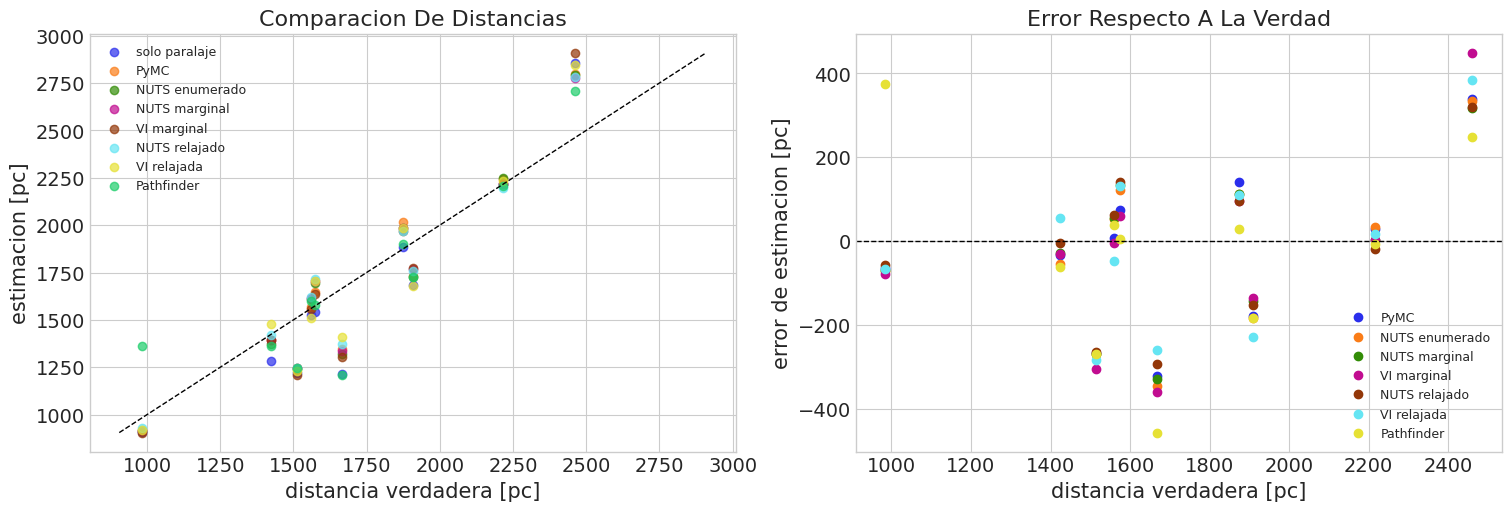

In [9]:
true_distance = pymc_results["true_distance"]
parallax_only = pymc_results["parallax_only"]
pymc_distance = pymc_results["posterior_distance"]
numpyro_distance = numpyro_results["posterior_distance"]
marginal_nuts_distance = marginal_nuts_results["posterior_distance"]
vi_distance = vi_results["posterior_distance"]
relaxed_nuts_distance = relaxed_nuts_results["posterior_distance"]
relaxed_distance = relaxed_results["posterior_distance"]
pathfinder_distance = pathfinder_results["posterior_distance"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
limits = [
    min(
        true_distance.min(),
        parallax_only.min(),
        pymc_distance.min(),
        numpyro_distance.min(),
        marginal_nuts_distance.min(),
        vi_distance.min(),
        relaxed_nuts_distance.min(),
        relaxed_distance.min(),
        pathfinder_distance.min(),
    ),
    max(
        true_distance.max(),
        parallax_only.max(),
        pymc_distance.max(),
        numpyro_distance.max(),
        marginal_nuts_distance.max(),
        vi_distance.max(),
        relaxed_nuts_distance.max(),
        relaxed_distance.max(),
        pathfinder_distance.max(),
    ),
]

axes[0].scatter(true_distance, parallax_only, alpha=0.7, label="solo paralaje")
axes[0].scatter(true_distance, pymc_distance, alpha=0.7, label="PyMC")
axes[0].scatter(true_distance, numpyro_distance, alpha=0.7, label="NUTS enumerado")
axes[0].scatter(true_distance, marginal_nuts_distance, alpha=0.7, label="NUTS marginal")
axes[0].scatter(true_distance, vi_distance, alpha=0.7, label="VI marginal")
axes[0].scatter(true_distance, relaxed_nuts_distance, alpha=0.7, label="NUTS relajado")
axes[0].scatter(true_distance, relaxed_distance, alpha=0.7, label="VI relajada")
axes[0].scatter(true_distance, pathfinder_distance, alpha=0.7, label="Pathfinder")
axes[0].plot(limits, limits, linestyle="--", color="black", linewidth=1)
axes[0].set_xlabel("distancia verdadera [pc]")
axes[0].set_ylabel("estimacion [pc]")
axes[0].set_title("Comparacion De Distancias")
axes[0].legend(fontsize=9)

axes[1].plot(true_distance, pymc_distance - true_distance, "o", label="PyMC")
axes[1].plot(true_distance, numpyro_distance - true_distance, "o", label="NUTS enumerado")
axes[1].plot(true_distance, marginal_nuts_distance - true_distance, "o", label="NUTS marginal")
axes[1].plot(true_distance, vi_distance - true_distance, "o", label="VI marginal")
axes[1].plot(true_distance, relaxed_nuts_distance - true_distance, "o", label="NUTS relajado")
axes[1].plot(true_distance, relaxed_distance - true_distance, "o", label="VI relajada")
axes[1].plot(true_distance, pathfinder_distance - true_distance, "o", label="Pathfinder")
axes[1].axhline(0.0, linestyle="--", color="black", linewidth=1)
axes[1].set_xlabel("distancia verdadera [pc]")
axes[1].set_ylabel("error de estimacion [pc]")
axes[1].set_title("Error Respecto A La Verdad")
axes[1].legend(fontsize=9)

Text(0.0, 0.95, 'Formulaciones comparadas:\n\n- PyMC marginalizado\n- NUTS enumerado\n- NUTS marginal\n- NUTS relajado\n- VI marginal\n- VI relajada\n- Pathfinder')

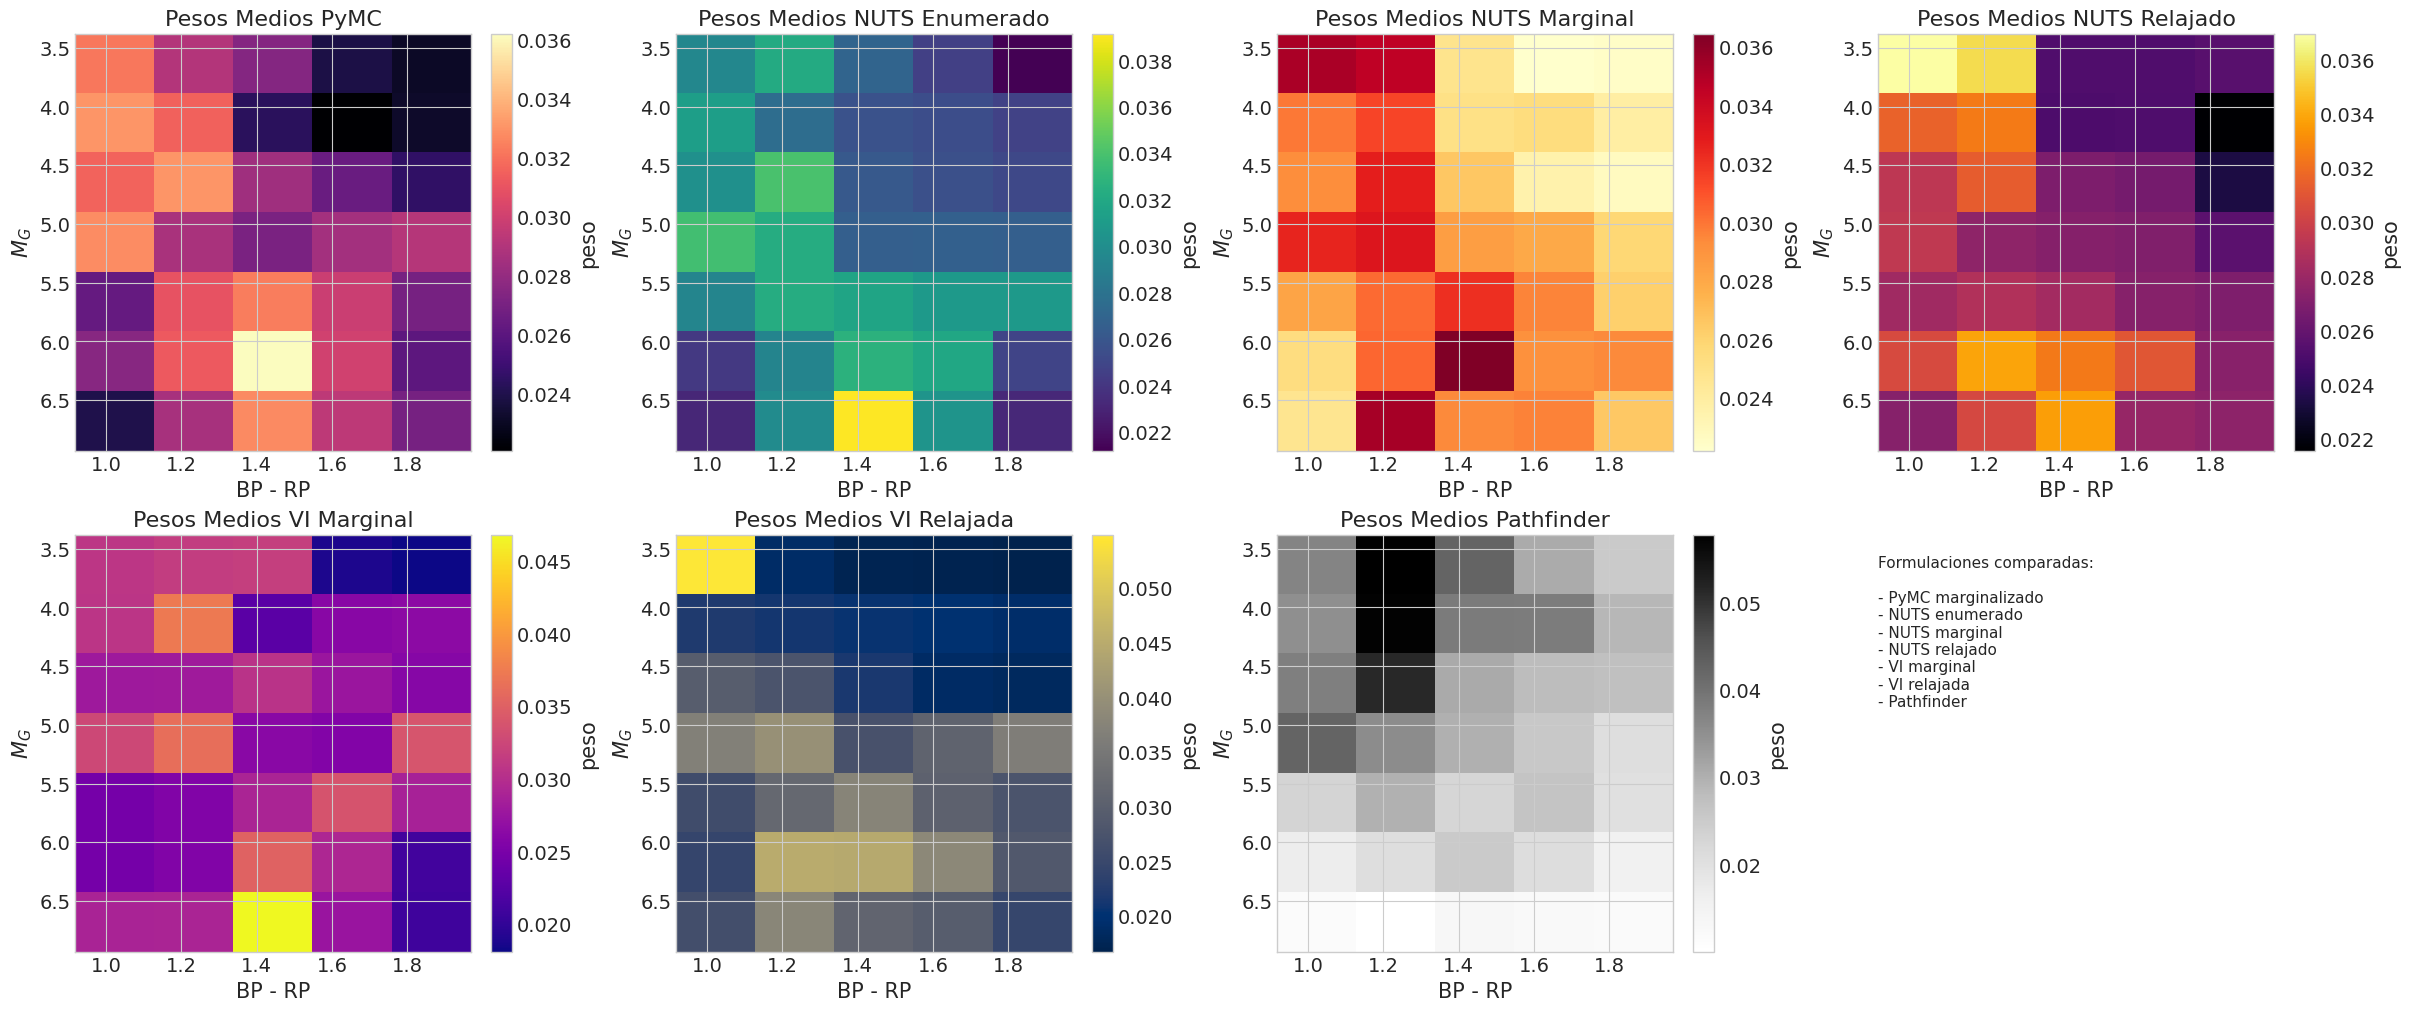

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10), constrained_layout=True)

pymc_weights = pymc_results["posterior_weights"]
numpyro_weights = numpyro_results["posterior_weights"]
marginal_nuts_weights = marginal_nuts_results["posterior_weights"]
vi_weights = vi_results["posterior_weights"]
relaxed_nuts_weights = relaxed_nuts_results["posterior_weights"]
relaxed_weights = relaxed_results["posterior_weights"]
pathfinder_weights = pathfinder_results["posterior_weights"]
extent = [
    pymc_results["color_edges"][0],
    pymc_results["color_edges"][-1],
    pymc_results["abs_edges"][0],
    pymc_results["abs_edges"][-1],
]

im0 = axes[0, 0].imshow(pymc_weights, aspect="auto", origin="lower", extent=extent, cmap="magma")
axes[0, 0].invert_yaxis()
axes[0, 0].set_title("Pesos Medios PyMC")
axes[0, 0].set_xlabel("BP - RP")
axes[0, 0].set_ylabel(r"$M_G$")
fig.colorbar(im0, ax=axes[0, 0], label="peso")

im1 = axes[0, 1].imshow(numpyro_weights, aspect="auto", origin="lower", extent=extent, cmap="viridis")
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Pesos Medios NUTS Enumerado")
axes[0, 1].set_xlabel("BP - RP")
axes[0, 1].set_ylabel(r"$M_G$")
fig.colorbar(im1, ax=axes[0, 1], label="peso")

im2 = axes[0, 2].imshow(marginal_nuts_weights, aspect="auto", origin="lower", extent=extent, cmap="YlOrRd")
axes[0, 2].invert_yaxis()
axes[0, 2].set_title("Pesos Medios NUTS Marginal")
axes[0, 2].set_xlabel("BP - RP")
axes[0, 2].set_ylabel(r"$M_G$")
fig.colorbar(im2, ax=axes[0, 2], label="peso")

im3 = axes[0, 3].imshow(relaxed_nuts_weights, aspect="auto", origin="lower", extent=extent, cmap="inferno")
axes[0, 3].invert_yaxis()
axes[0, 3].set_title("Pesos Medios NUTS Relajado")
axes[0, 3].set_xlabel("BP - RP")
axes[0, 3].set_ylabel(r"$M_G$")
fig.colorbar(im3, ax=axes[0, 3], label="peso")

im4 = axes[1, 0].imshow(vi_weights, aspect="auto", origin="lower", extent=extent, cmap="plasma")
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("Pesos Medios VI Marginal")
axes[1, 0].set_xlabel("BP - RP")
axes[1, 0].set_ylabel(r"$M_G$")
fig.colorbar(im4, ax=axes[1, 0], label="peso")

im5 = axes[1, 1].imshow(relaxed_weights, aspect="auto", origin="lower", extent=extent, cmap="cividis")
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Pesos Medios VI Relajada")
axes[1, 1].set_xlabel("BP - RP")
axes[1, 1].set_ylabel(r"$M_G$")
fig.colorbar(im5, ax=axes[1, 1], label="peso")

im6 = axes[1, 2].imshow(pathfinder_weights, aspect="auto", origin="lower", extent=extent, cmap="Greys")
axes[1, 2].invert_yaxis()
axes[1, 2].set_title("Pesos Medios Pathfinder")
axes[1, 2].set_xlabel("BP - RP")
axes[1, 2].set_ylabel(r"$M_G$")
fig.colorbar(im6, ax=axes[1, 2], label="peso")

axes[1, 3].axis("off")
axes[1, 3].text(
    0.0,
    0.95,
    "Formulaciones comparadas:\n\n- PyMC marginalizado\n- NUTS enumerado\n- NUTS marginal\n- NUTS relajado\n- VI marginal\n- VI relajada\n- Pathfinder",
    va="top",
    ha="left",
    fontsize=11,
 )

In [12]:
def summarize_weight_means(idata, label, use_arviz=True):
    print(label)
    if use_arviz:
        display(az.summary(idata, var_names=["weights"], kind="stats", round_to=3).head())
        return

    weights = np.asarray(idata.posterior["weights"]).reshape(-1, idata.posterior["weights"].shape[-1])
    summary = pd.DataFrame({
        "mean": weights.mean(axis=0),
        "sd": weights.std(axis=0),
        "hdi_3%": np.quantile(weights, 0.03, axis=0),
        "hdi_97%": np.quantile(weights, 0.97, axis=0),
    })
    display(summary.head().round(3))

summarize_weight_means(pymc_idata, "Resumen PyMC")
summarize_weight_means(numpyro_idata, "Resumen NUTS enumerado")
summarize_weight_means(marginal_nuts_idata, "Resumen NUTS marginal")
summarize_weight_means(vi_idata, "Resumen VI marginal", use_arviz=False)
summarize_weight_means(relaxed_nuts_idata, "Resumen NUTS relajado")
summarize_weight_means(relaxed_idata, "Resumen VI relajada", use_arviz=False)
summarize_weight_means(pathfinder_idata, "Resumen Pathfinder", use_arviz=False)

Resumen PyMC


,mean,sd,hdi_3%,hdi_97%
weights[0],0.032,0.029,0.0,0.091
weights[1],0.029,0.026,0.0,0.081
weights[2],0.027,0.024,0.0,0.071
weights[3],0.024,0.024,0.0,0.070
weights[4],0.023,0.020,0.0,0.061


Resumen NUTS enumerado


,mean,sd,hdi_3%,hdi_97%
weights[0],0.029,0.028,0.0,0.085
weights[1],0.032,0.027,0.0,0.079
weights[2],0.027,0.023,0.0,0.073
weights[3],0.025,0.022,0.0,0.068
weights[4],0.021,0.020,0.0,0.058


Resumen NUTS marginal


...

,mean,sd,hdi_3%,hdi_97%
weights[0],0.037,0.032,0.0,0.101
weights[1],0.036,0.032,0.0,0.093
weights[2],0.025,0.023,0.0,0.069
weights[3],0.025,0.023,0.0,0.068
weights[4],0.025,0.029,0.0,0.075


Resumen VI relajada


,mean,sd,hdi_3%,hdi_97%
0,0.055,0.022,0.025,0.107
1,0.019,0.018,0.003,0.063
2,0.017,0.016,0.002,0.059
3,0.017,0.016,0.003,0.056
4,0.017,0.016,0.003,0.055


Resumen Pathfinder


,mean,sd,hdi_3%,hdi_97%
0,0.037,0.025,0.009,0.099
1,0.058,0.037,0.015,0.145
2,0.042,0.027,0.010,0.106
3,0.031,0.020,0.008,0.076
4,0.025,0.016,0.007,0.064
